In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/House_Price_Prediction_dataset.csv")
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


In [5]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

In [6]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.00,3.00,1.50,1340,7912,1.50,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.00,5.00,2.50,3650,9050,2.00,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.00,3.00,2.00,1930,11947,1.00,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.00,3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.00,4.00,2.50,1940,10500,1.00,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [7]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00,4600.00
mean,551962.99,3.40,2.16,2139.35,14852.52,1.51,0.01,0.24,3.45,1827.27,312.08,1970.79,808.61
std,563834.70,0.91,0.78,963.21,35884.44,0.54,0.08,0.78,0.68,862.17,464.14,29.73,979.41
min,0.00,0.00,0.00,370.00,638.00,1.00,0.00,0.00,1.00,370.00,0.00,1900.00,0.00
25%,322875.00,3.00,1.75,1460.00,5000.75,1.00,0.00,0.00,3.00,1190.00,0.00,1951.00,0.00
50%,460943.46,3.00,2.25,1980.00,7683.00,1.50,0.00,0.00,3.00,1590.00,0.00,1976.00,0.00
75%,654962.50,4.00,2.50,2620.00,11001.25,2.00,0.00,0.00,4.00,2300.00,610.00,1997.00,1999.00
max,26590000.00,9.00,8.00,13540.00,1074218.00,3.50,1.00,4.00,5.00,9410.00,4820.00,2014.00,2014.00


In [10]:
df.dtypes

,0
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


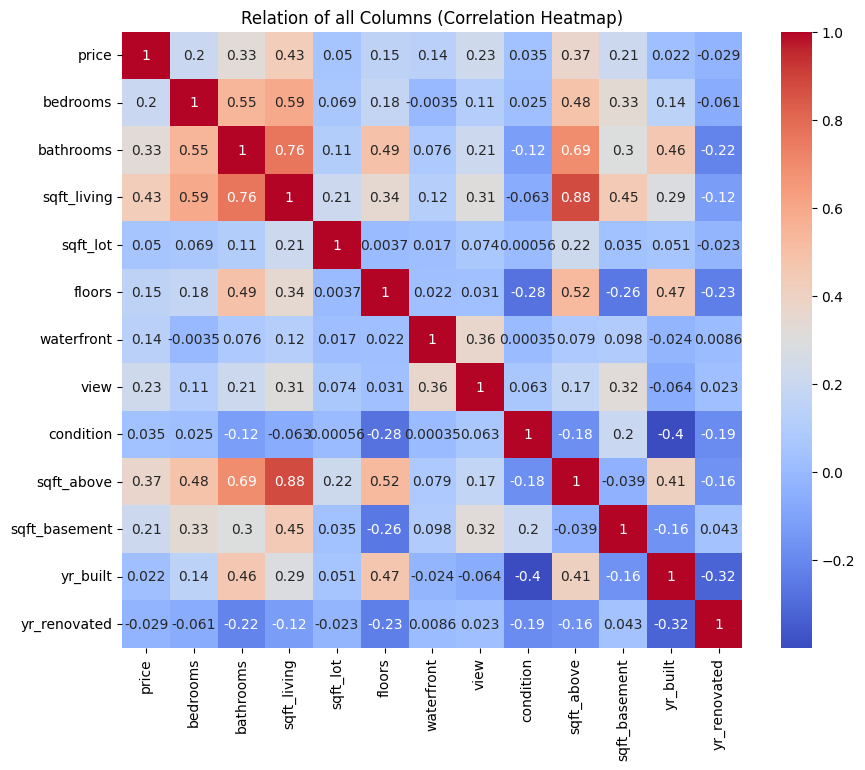

In [14]:
# EDA
# check relation of all numeric cloumns
plt.figure(figsize=(10, 8))

sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm")
plt.title("Relation of all Columns (Correlation Heatmap)")
plt.show()

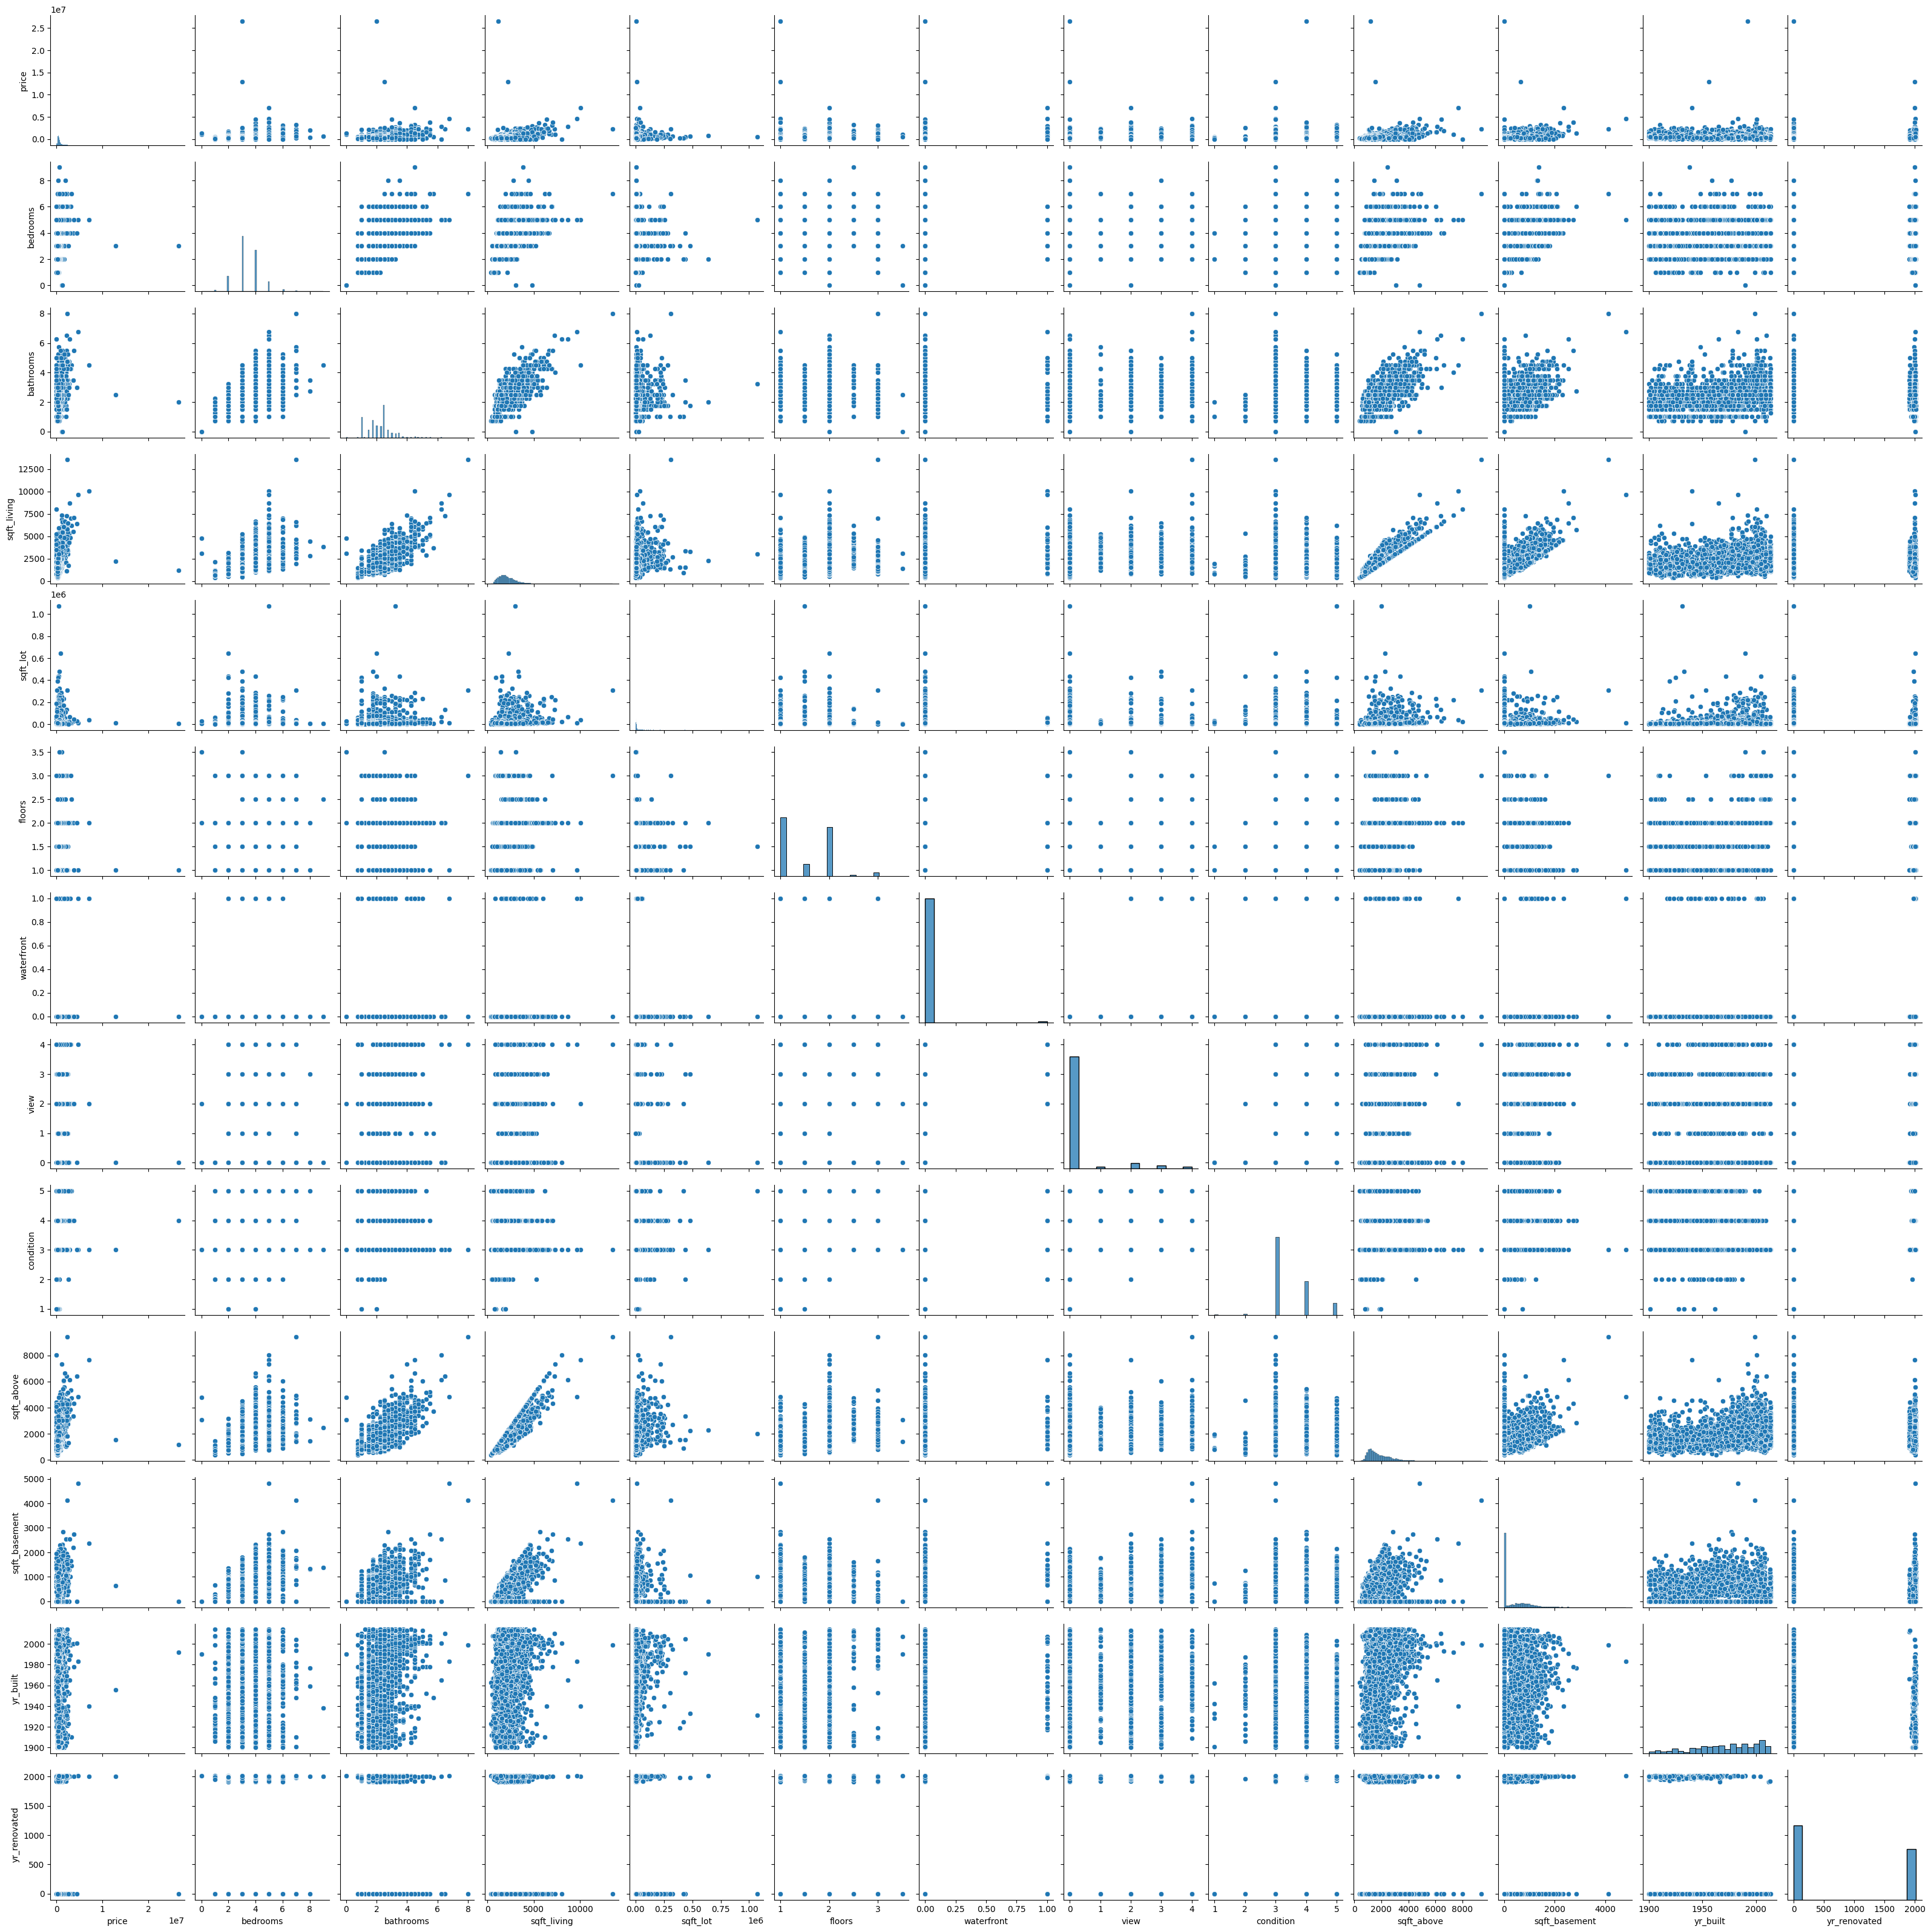

In [17]:
sns.pairplot(df)
plt.show()

In [11]:
df_final = df[["price","bedrooms","bathrooms","sqft_living","sqft_lot","floors","waterfront","view","condition","sqft_above","sqft_basement","street","city","statezip","country"]].copy()
df_final

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,street,city,statezip,country
0,313000.00,3.00,1.50,1340,7912,1.50,0,0,3,1340,0,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2384000.00,5.00,2.50,3650,9050,2.00,0,4,5,3370,280,709 W Blaine St,Seattle,WA 98119,USA
2,342000.00,3.00,2.00,1930,11947,1.00,0,0,4,1930,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,420000.00,3.00,2.25,2000,8030,1.00,0,0,4,1000,1000,857 170th Pl NE,Bellevue,WA 98008,USA
4,550000.00,4.00,2.50,1940,10500,1.00,0,0,4,1140,800,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308166.67,3.00,1.75,1510,6360,1.00,0,0,4,1510,0,501 N 143rd St,Seattle,WA 98133,USA
4596,534333.33,3.00,2.50,1460,7573,2.00,0,0,3,1460,0,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,416904.17,3.00,2.50,3010,7014,2.00,0,0,3,3010,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,203400.00,4.00,2.00,2090,6630,1.00,0,0,3,1070,1020,5148 S Creston St,Seattle,WA 98178,USA


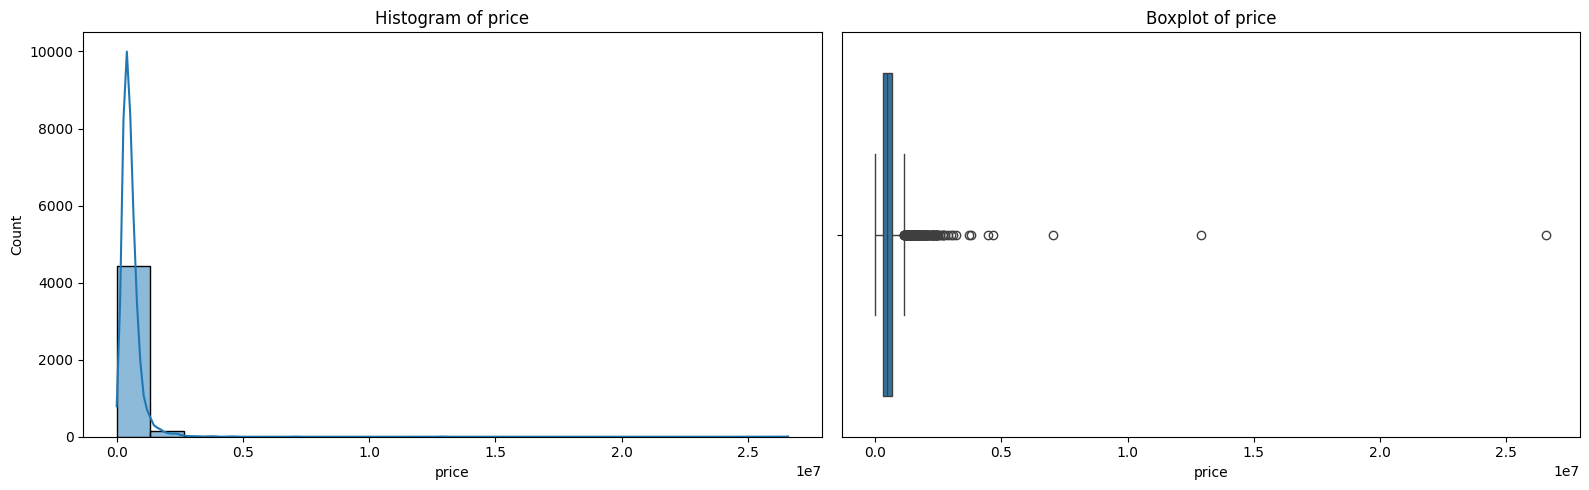

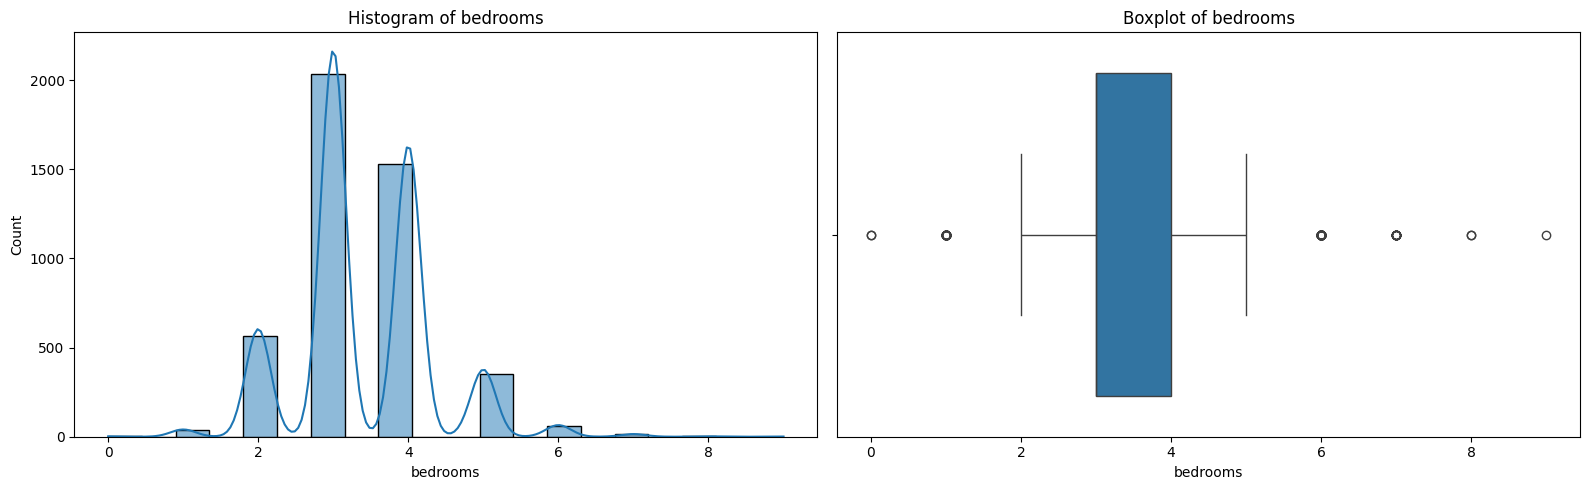

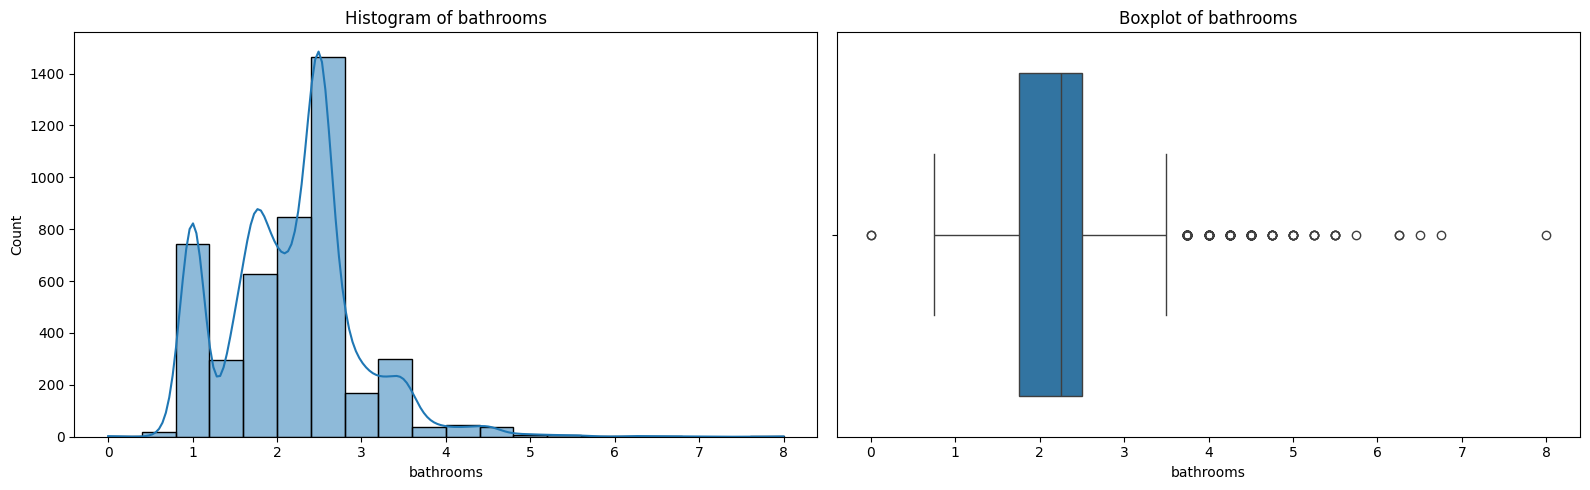

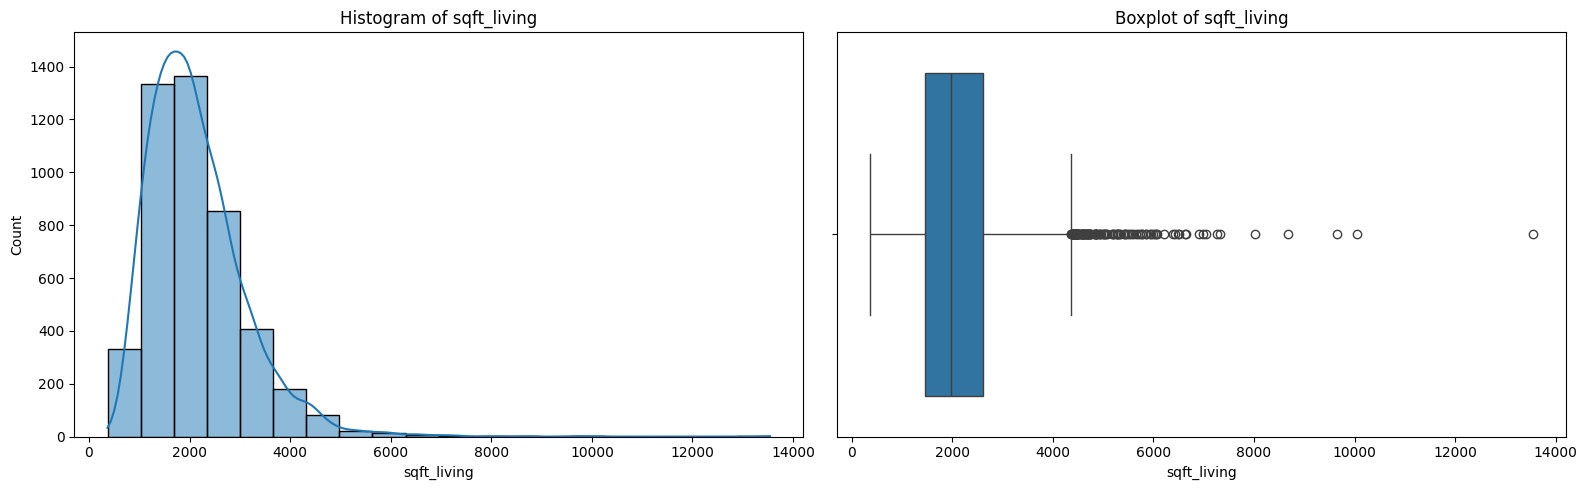

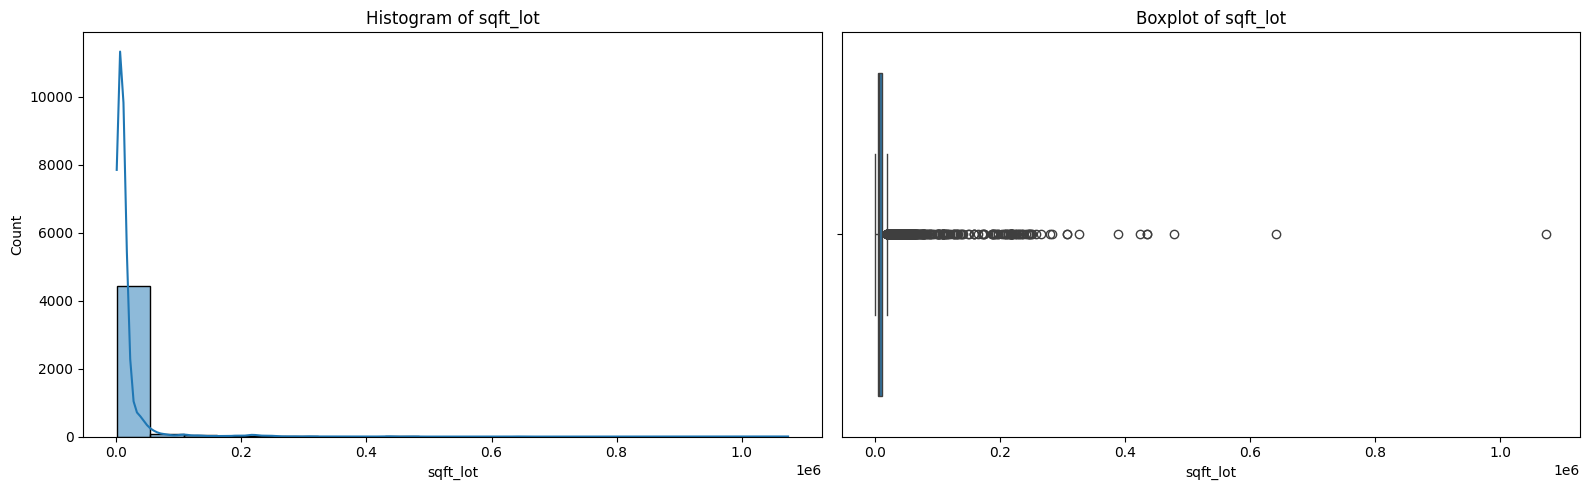

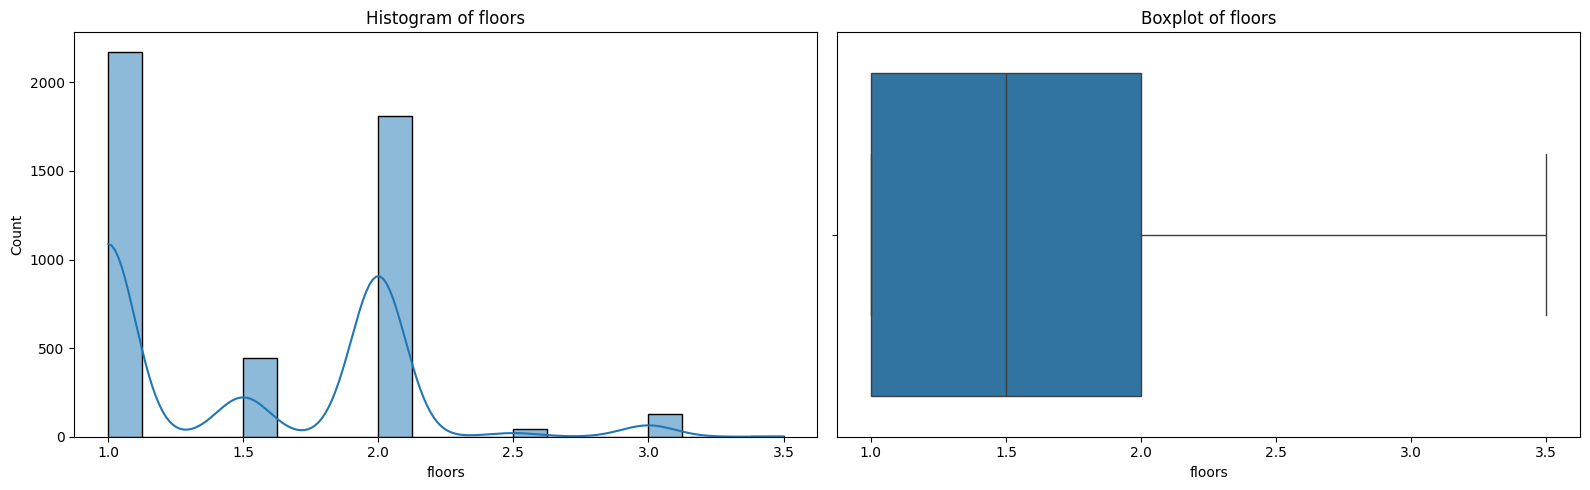

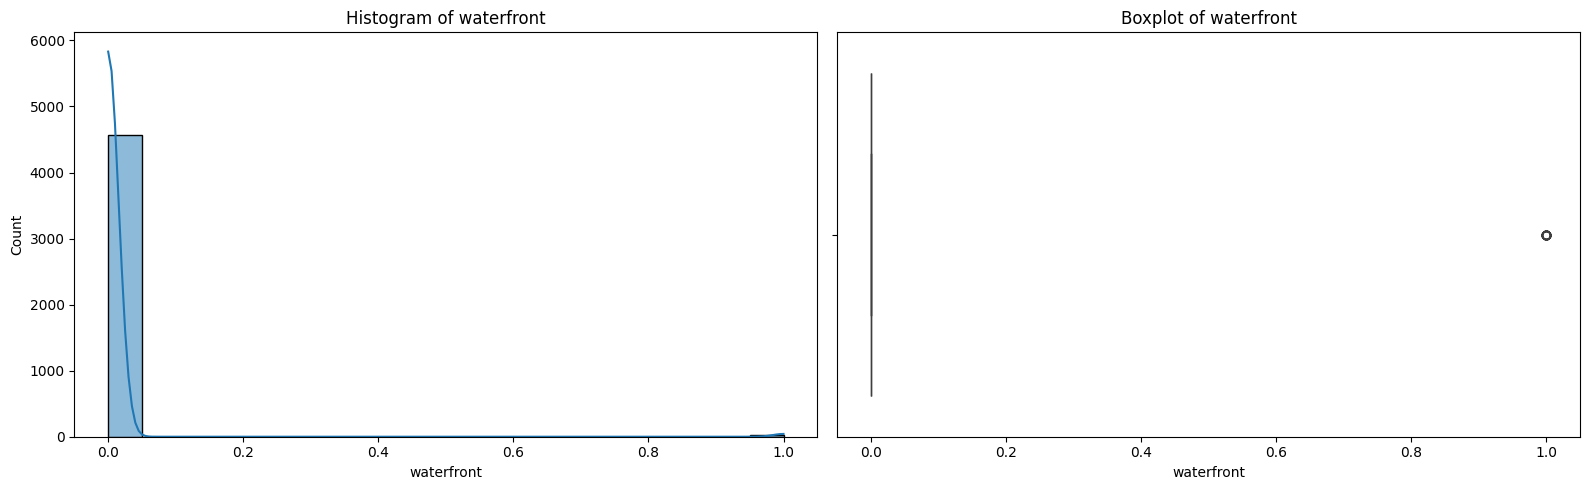

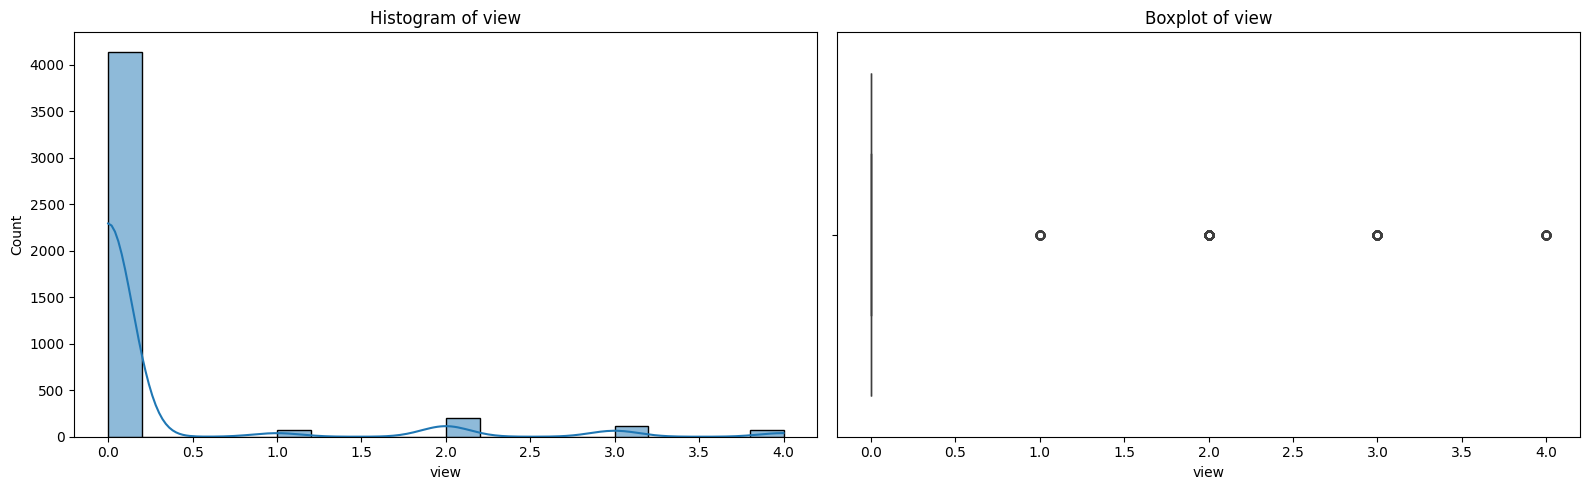

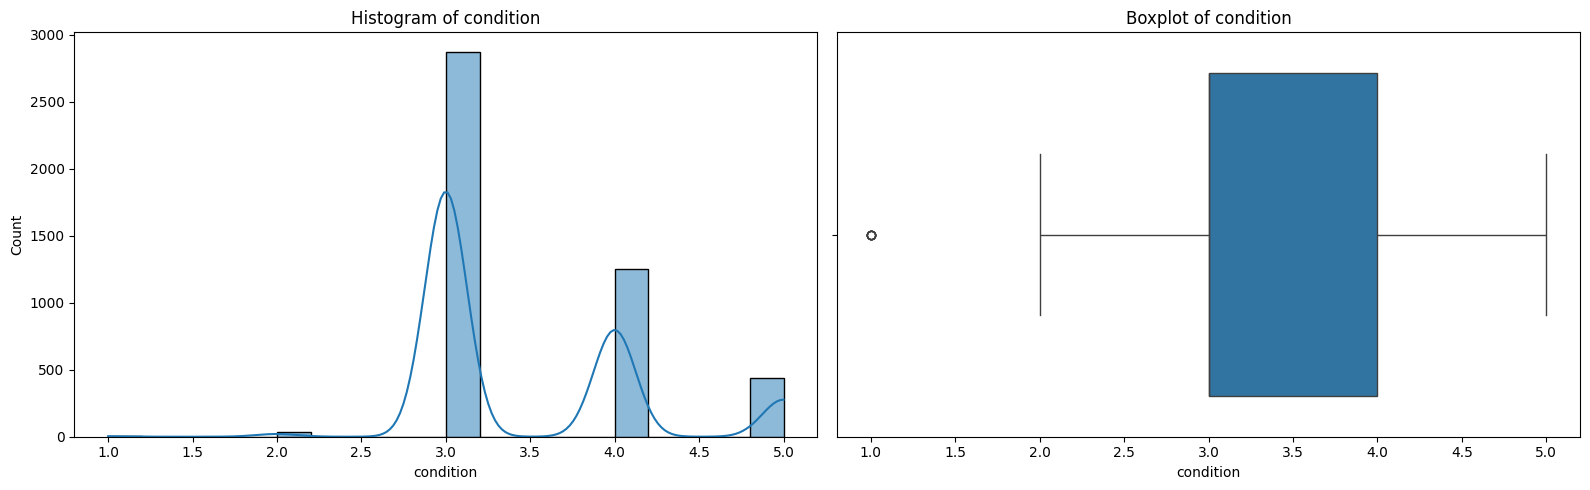

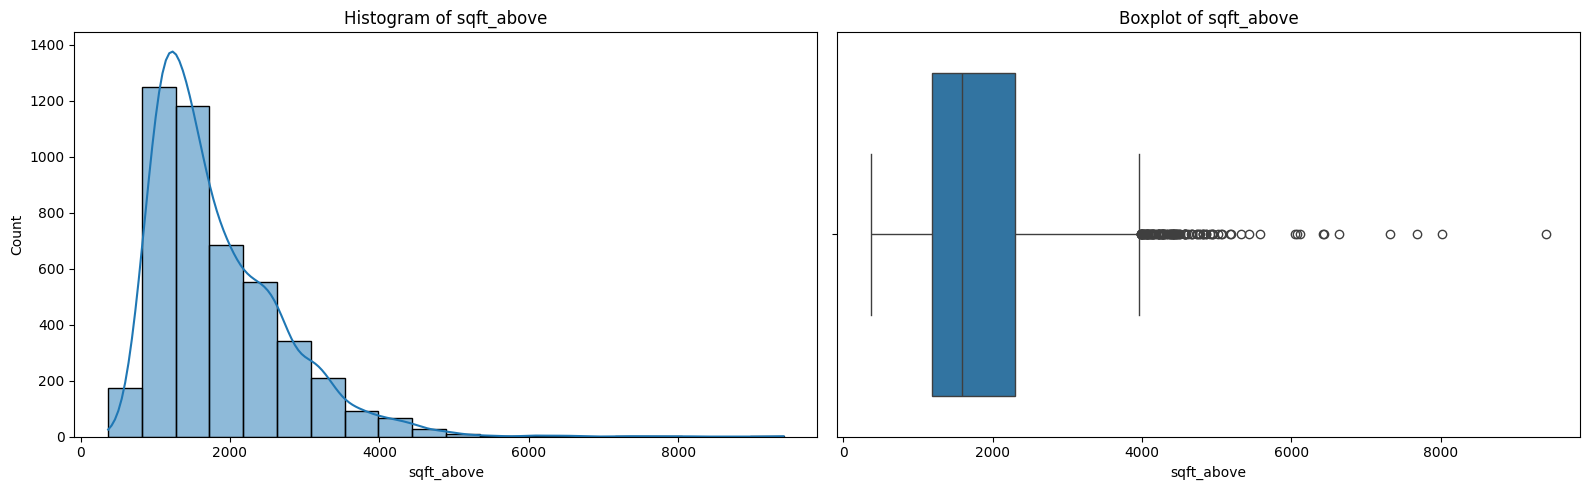

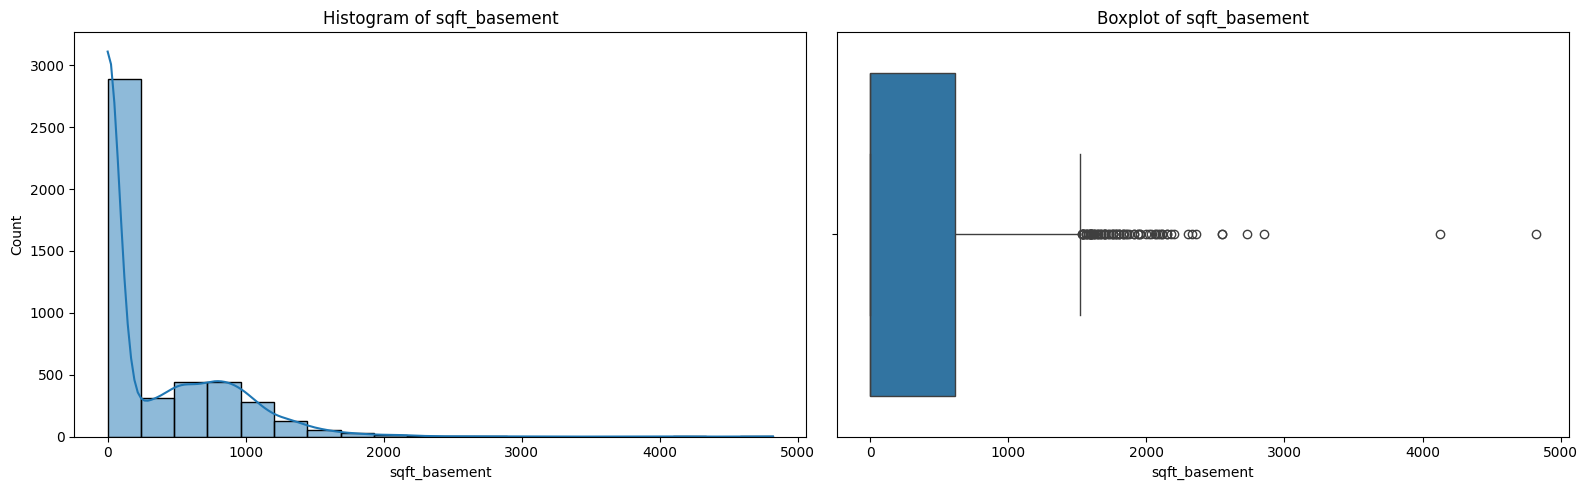

In [ ]:
column = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "condition", "sqft_above", "sqft_basement"]
for col in column:

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df_final[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 2, 2)

    sns.boxplot(x=df_final[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
df_clean = df_final.copy()

numeric_column = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "condition", "sqft_above", "sqft_basement"]

for col in numeric_column:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_clean[col] = np.where(
    df_clean[col] > upper_limit,
    upper_limit,
    np.where(
        df_clean[col] < lower_limit,
        lower_limit,
        df_clean[col]
    )
)

print("Remove all outliers from all numeric columns by capping method")

Remove all outliers from all numeric columns by capping method


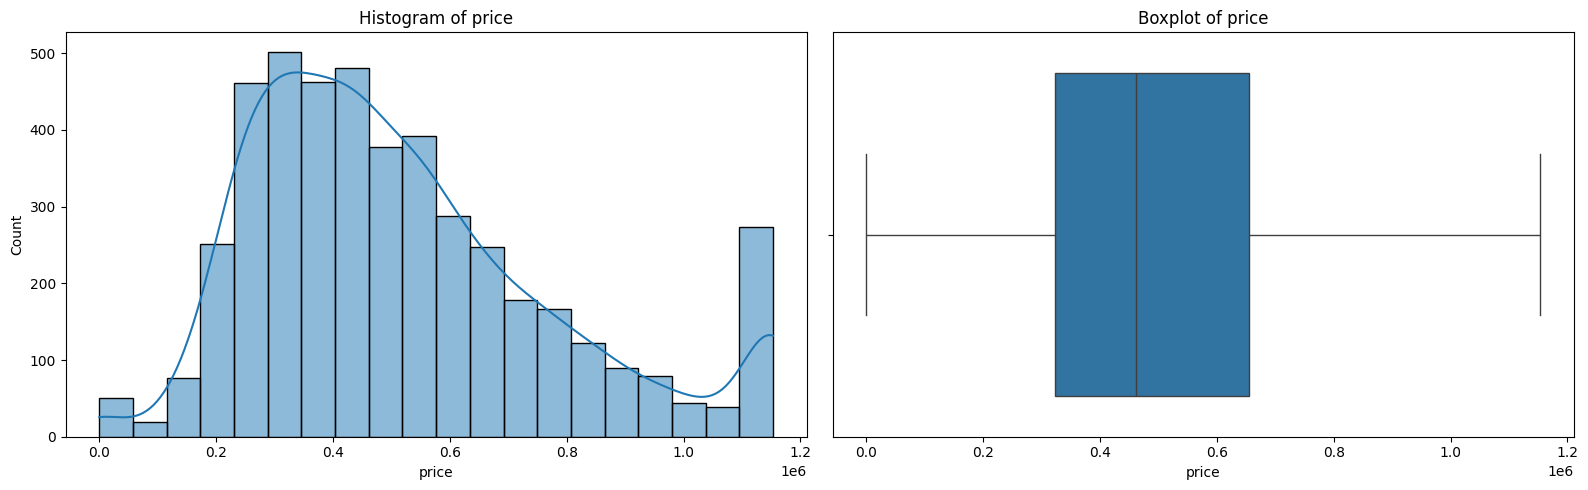

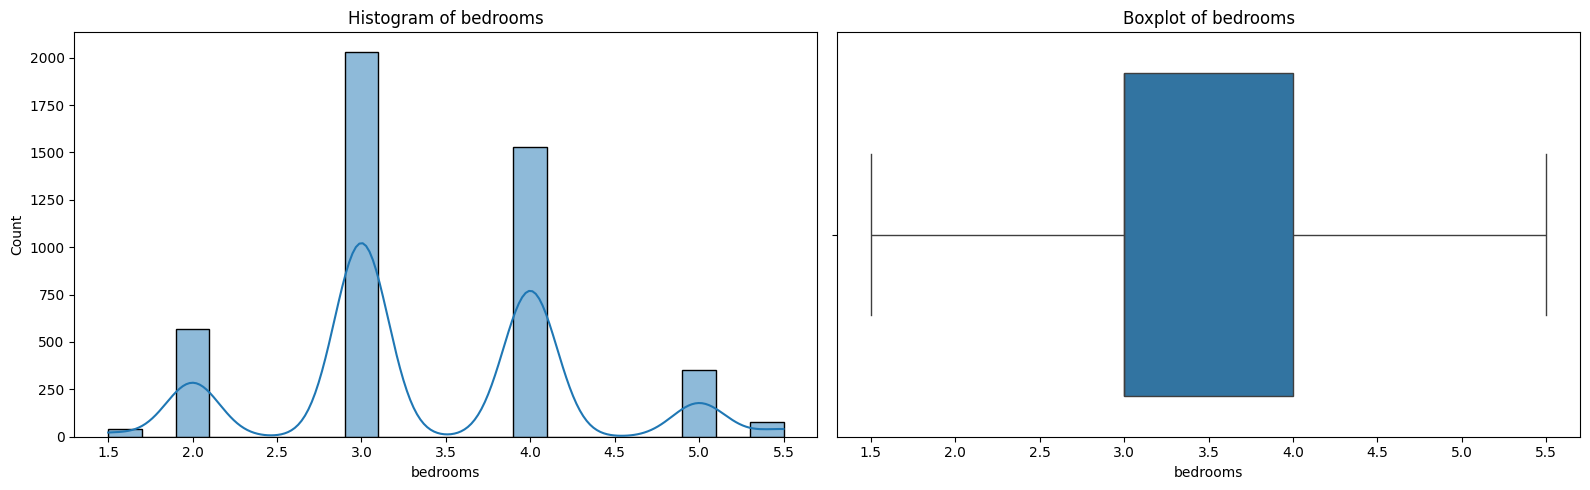

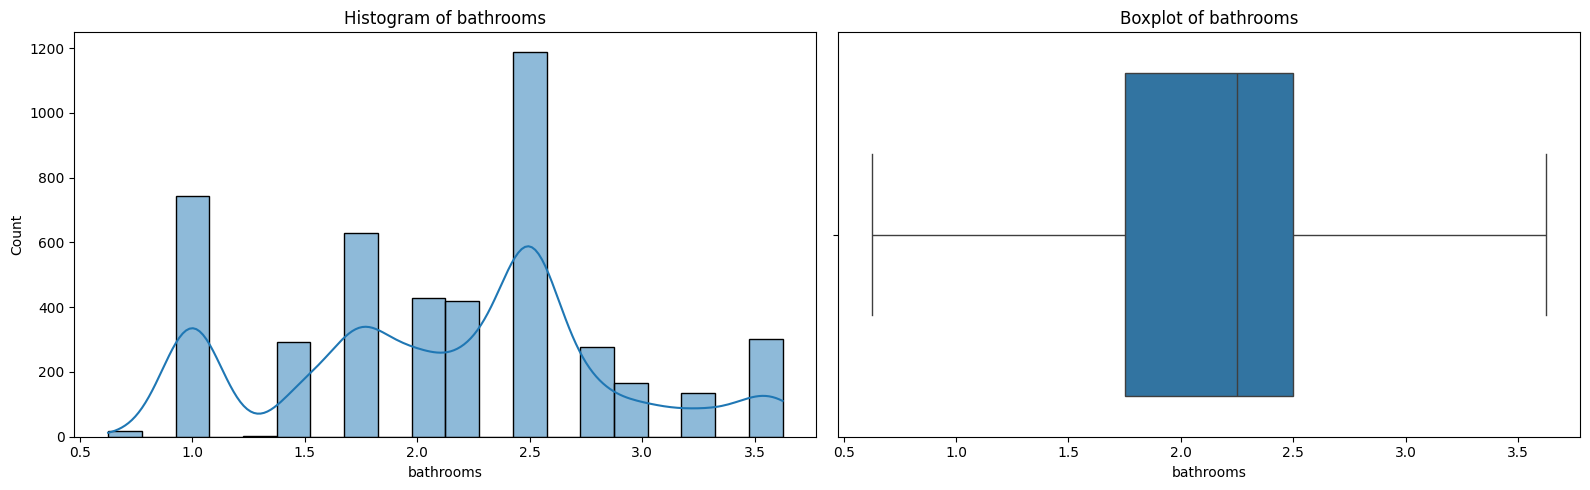

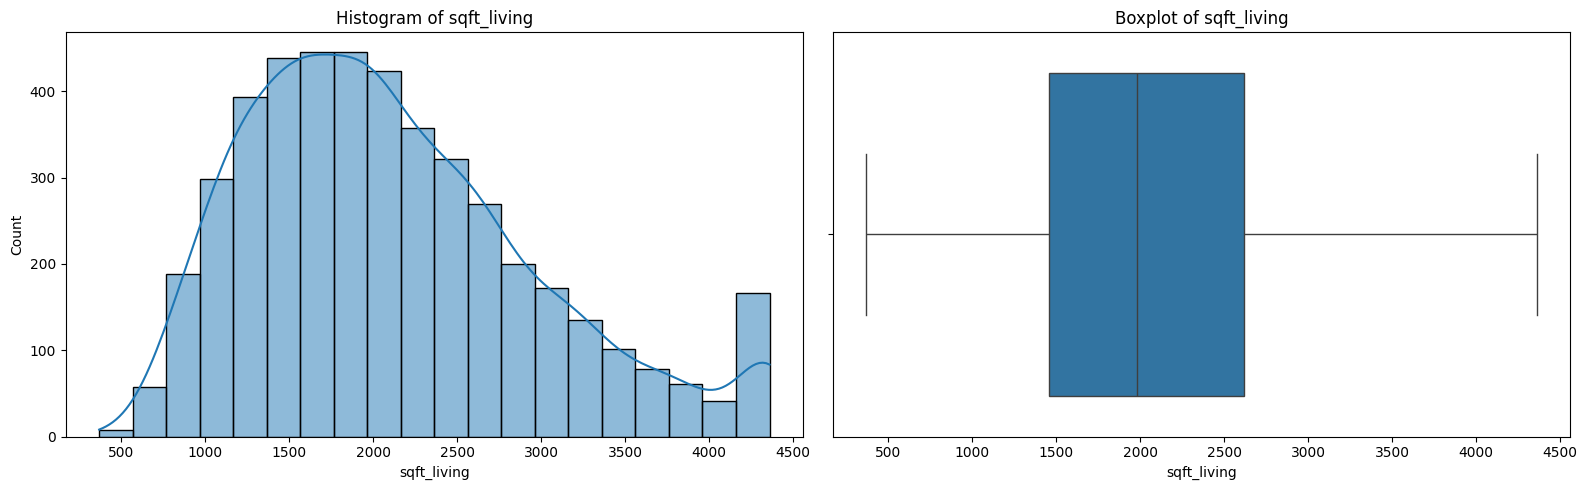

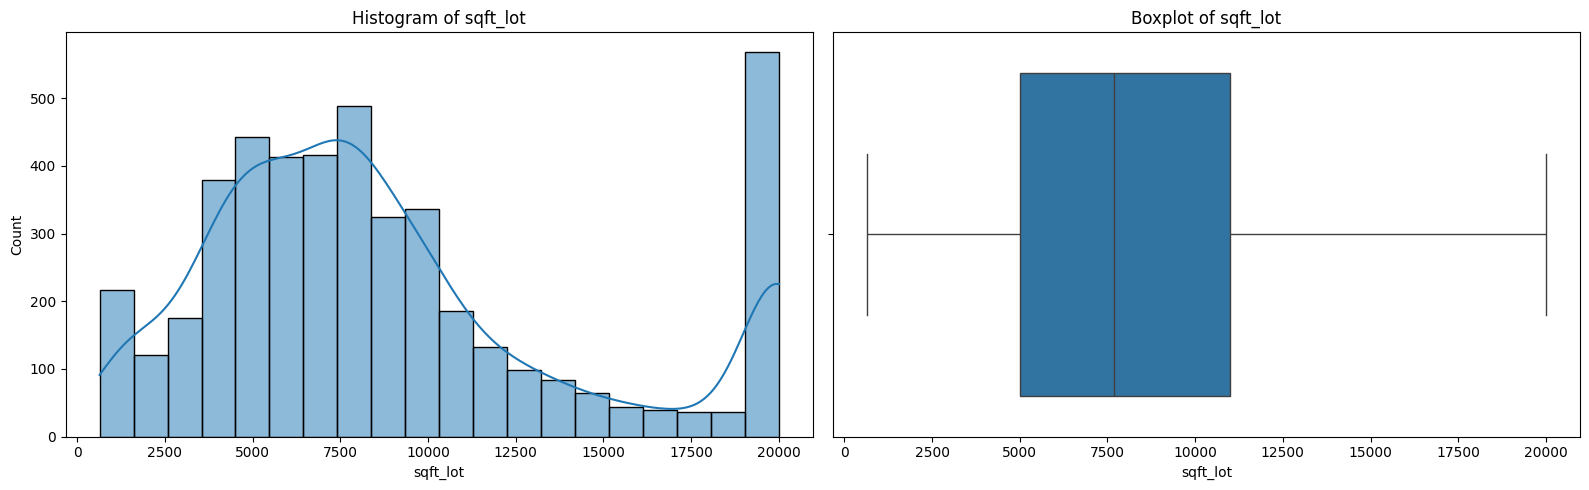

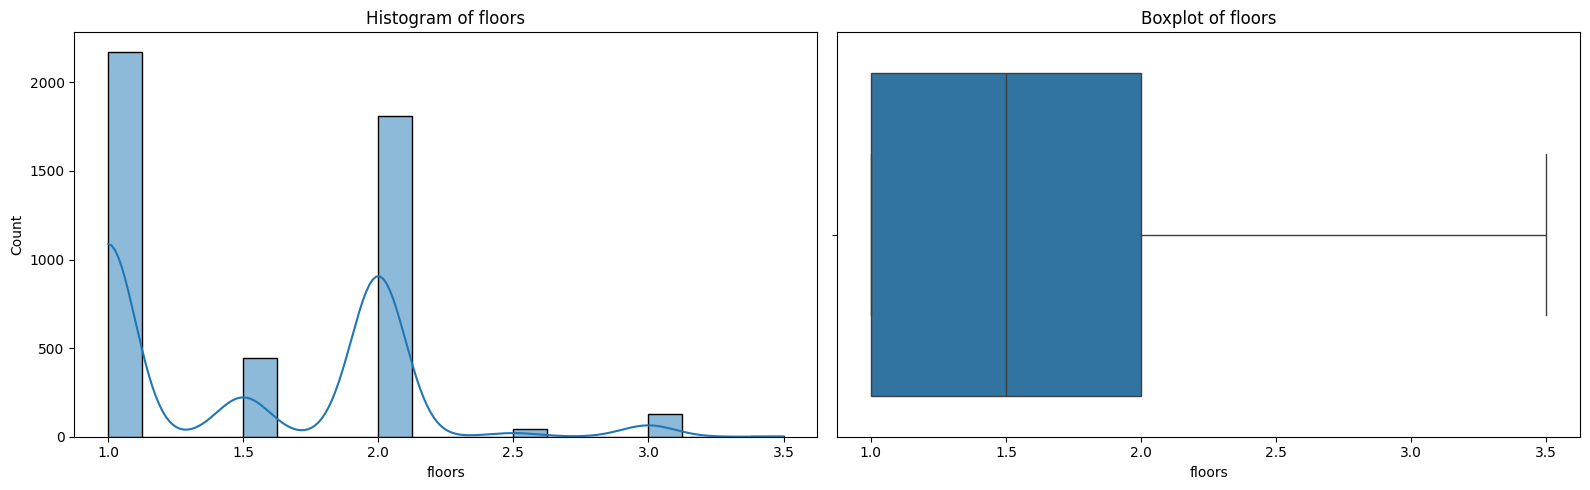

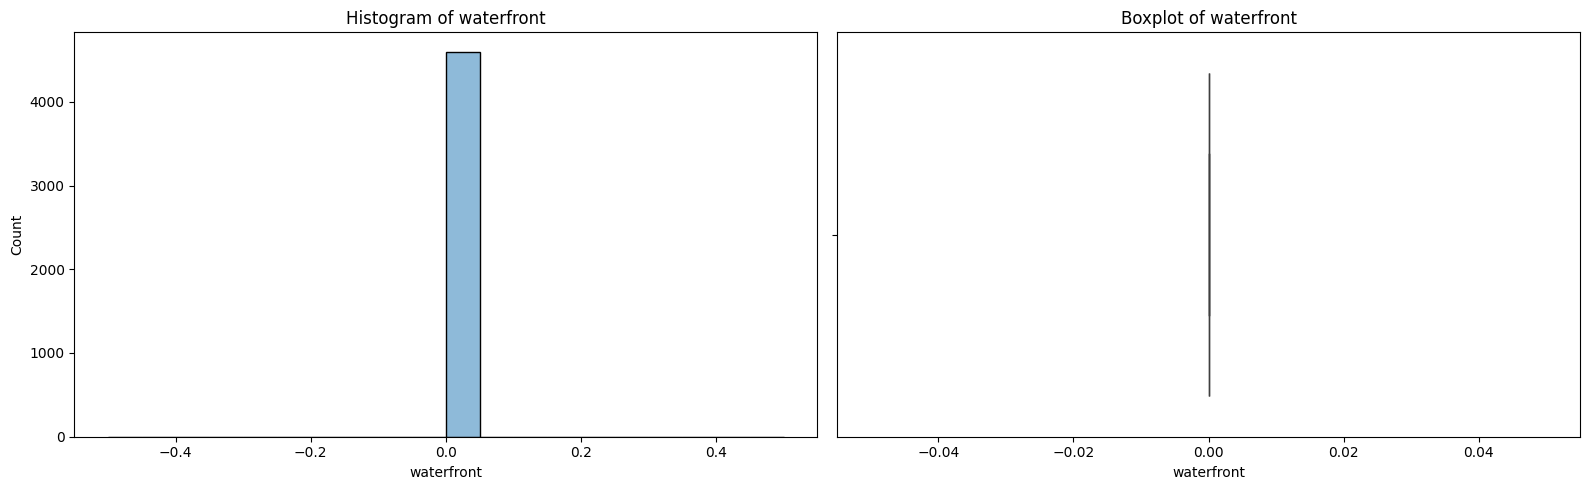

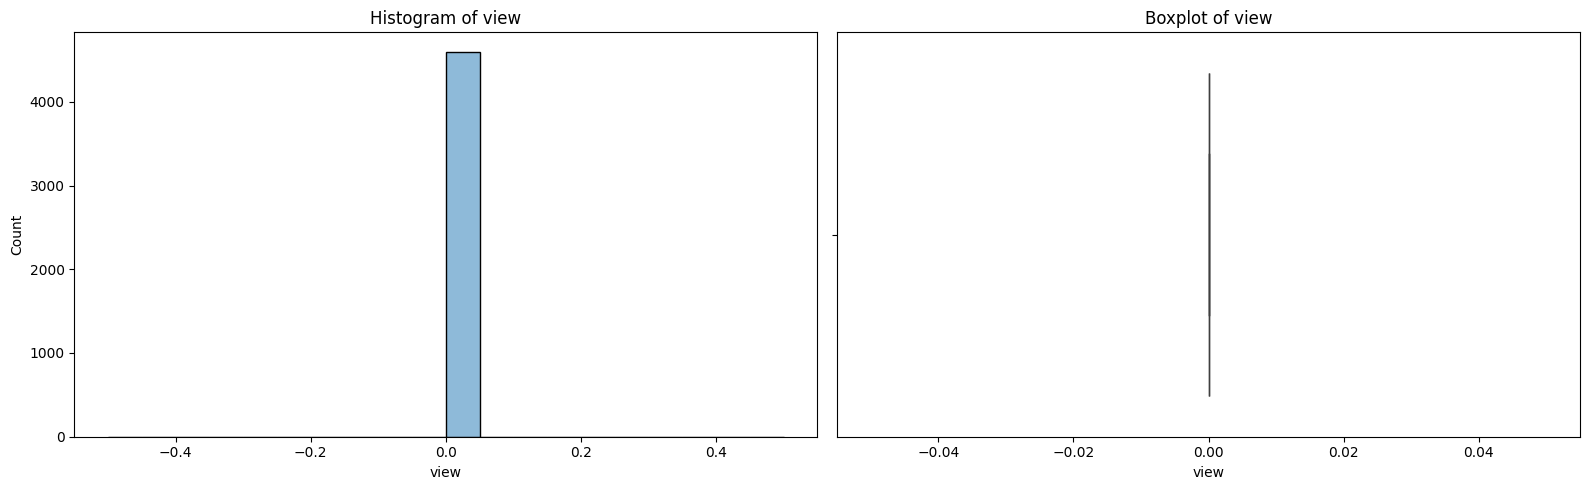

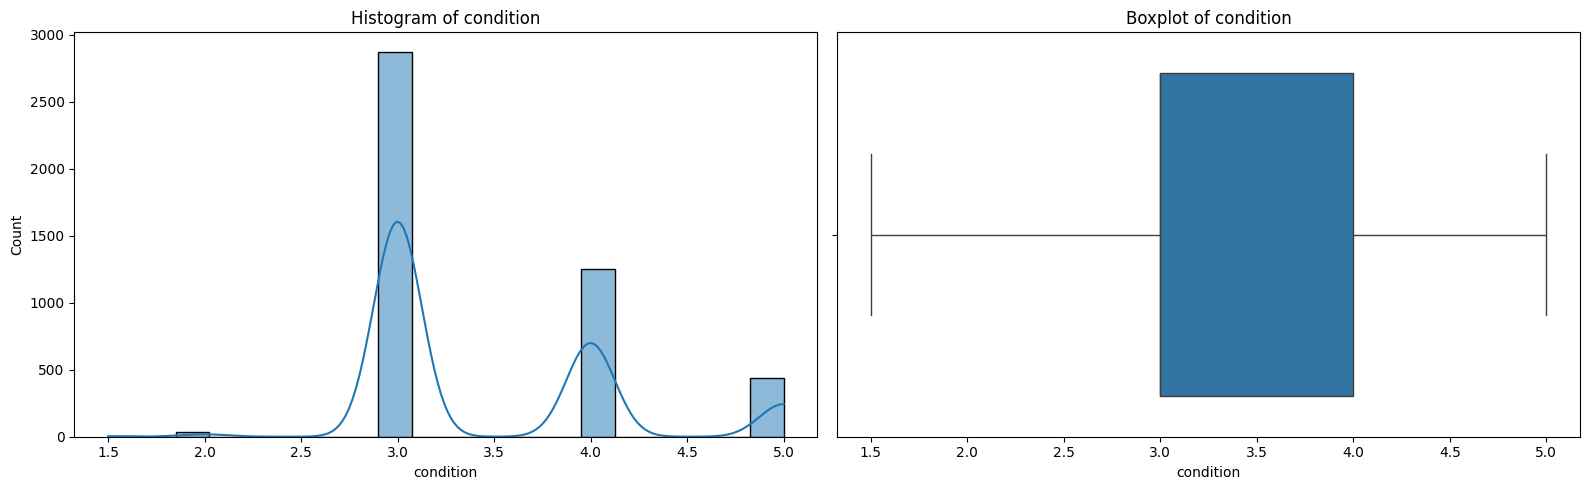

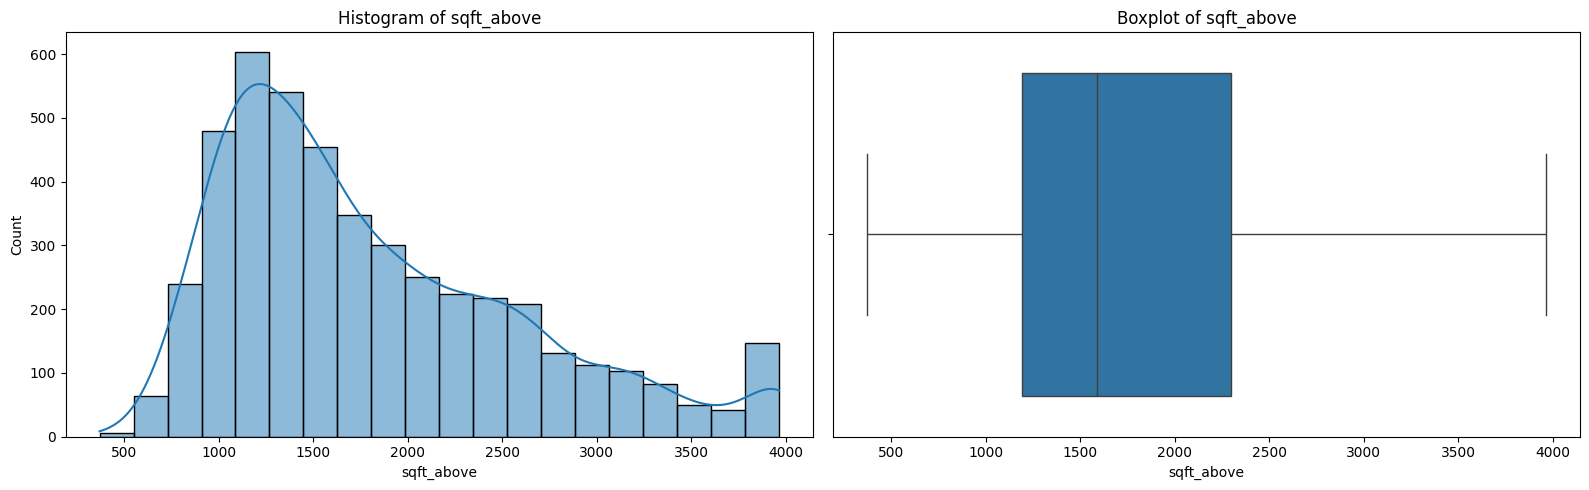

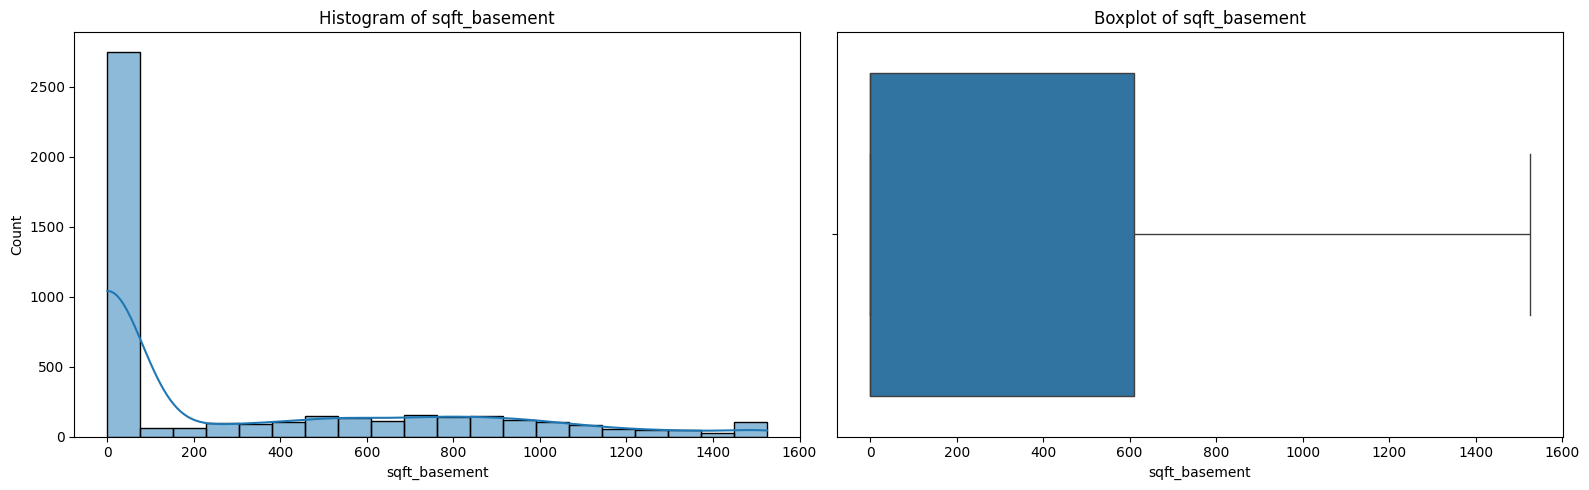

In [ ]:
column = ["price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors", "waterfront", "view", "condition", "sqft_above", "sqft_basement"]
for col in column:

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(df_clean[col], bins=20, kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 2, 2)

    sns.boxplot(x=df_clean[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

In [ ]:
df_clean = pd.get_dummies(df_clean, columns=["street", "city", "statezip", "country"], drop_first=True)
df_clean

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,313000.00,3.00,1.50,1340.00,7912.00,1.50,0.00,0.00,3.00,1340.00,...,False,False,False,False,False,False,False,False,False,False
1,1153093.75,5.00,2.50,3650.00,9050.00,2.00,0.00,0.00,5.00,3370.00,...,False,False,False,False,False,False,False,False,False,False
2,342000.00,3.00,2.00,1930.00,11947.00,1.00,0.00,0.00,4.00,1930.00,...,False,False,False,False,False,False,False,False,False,False
3,420000.00,3.00,2.25,2000.00,8030.00,1.00,0.00,0.00,4.00,1000.00,...,False,False,False,False,False,False,False,False,False,False
4,550000.00,4.00,2.50,1940.00,10500.00,1.00,0.00,0.00,4.00,1140.00,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,308166.67,3.00,1.75,1510.00,6360.00,1.00,0.00,0.00,4.00,1510.00,...,False,False,False,False,False,False,False,False,False,False
4596,534333.33,3.00,2.50,1460.00,7573.00,2.00,0.00,0.00,3.00,1460.00,...,False,False,False,False,False,False,False,False,False,False
4597,416904.17,3.00,2.50,3010.00,7014.00,2.00,0.00,0.00,3.00,3010.00,...,False,False,False,False,False,False,False,False,False,False
4598,203400.00,4.00,2.00,2090.00,6630.00,1.00,0.00,0.00,3.00,1070.00,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
y = df_clean["price"]
x = df_clean.drop("price", axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_predict = model.predict(x_test)

In [ ]:
accuracy = r2_score(y_test, y_predict)
print(f"Accuracy of the model is: {accuracy:.2f}")

Accuracy of the model is: 0.47


In [ ]:
row_number = (int(input("Enter a row number:")))

test_input = x_test.iloc[[row_number]]

original_price = y_test.iloc[row_number]

predicted_price = model.predict(test_input)[0]

difference = abs(original_volume - predicted_volume)

print(f"TEST DATA PREDICTION CHECK (Row No: {row_number})")
print(f"Original price    :  {original_price:.2f}")
print(f"Predict price   :  {predicted_price:.2f}")
print(f"Difference     :  {difference:.2f}")

Enter a row number:5
TEST DATA PREDICTION CHECK (Row No: 5)
Original Volume    :  625000.00
Predict Volume   :  548854.55
Farq (Difference)     :  76145.45
